In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# -----------------------------
# Load data
# -----------------------------
path = "predict+students+dropout+and+academic+success/data.csv"
df = pd.read_csv(path)

# Remove hidden spaces/tabs from column names
df.columns = df.columns.str.strip()

# -----------------------------
# Basic dataset summary
# -----------------------------
print("=== DATASET SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["Target"].value_counts())

=== DATASET SUMMARY ===
Shape: (4424, 37)
Duplicate rows: 0

Missing values per column:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                      

In [24]:
target = "Target"

categorical = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numerical = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

X = df.drop(columns=[target])
y = df[target]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\n=== TARGET ENCODING ===")
print("Classes:", list(label_encoder.classes_))


=== TARGET ENCODING ===
Classes: ['Dropout', 'Enrolled', 'Graduate']


In [25]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical),
        ("cat", categorical_transformer, categorical)
    ]
)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\n=== TRAIN / TEST SPLIT ===")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


=== TRAIN / TEST SPLIT ===
Train shape: (3539, 36)
Test shape: (885, 36)


In [27]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test, class_names, show_cm=True):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average="macro")
    rec_macro = recall_score(y_test, y_pred, average="macro")
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(f"Accuracy        : {acc:.4f}")
    print(f"Macro Precision : {prec_macro:.4f}")
    print(f"Macro Recall    : {rec_macro:.4f}")
    print(f"Macro F1-score  : {f1_macro:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    if show_cm:
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro Precision": prec_macro,
        "Macro Recall": rec_macro,
        "Macro F1": f1_macro
    }

In [28]:
def evaluate_model_detailed(name, pipeline, X_train, X_test, y_train, y_test, class_names, show_cm=True):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(f"Accuracy        : {acc:.4f}")
    print(f"Macro Precision : {report['macro avg']['precision']:.4f}")
    print(f"Macro Recall    : {report['macro avg']['recall']:.4f}")
    print(f"Macro F1-score  : {report['macro avg']['f1-score']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    if show_cm:
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    row = {
        "Model": name,
        "Accuracy": acc,
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"]
    }

    for cls in class_names:
        row[f"{cls} Precision"] = report[cls]["precision"]
        row[f"{cls} Recall"] = report[cls]["recall"]
        row[f"{cls} F1"] = report[cls]["f1-score"]

    return row


=== LOGISTIC REGRESSION TUNING ===
Best params: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'saga'}
Best CV Macro F1: 0.7154

MODEL: Logistic Regression (Tuned)
Accuracy        : 0.7345
Macro Precision : 0.7063
Macro Recall    : 0.7103
Macro F1-score  : 0.6976

Classification Report:
              precision    recall  f1-score   support

     Dropout     0.8298    0.6866    0.7514       284
    Enrolled     0.4221    0.6478    0.5112       159
    Graduate     0.8670    0.7964    0.8302       442

    accuracy                         0.7345       885
   macro avg     0.7063    0.7103    0.6976       885
weighted avg     0.7751    0.7345    0.7476       885



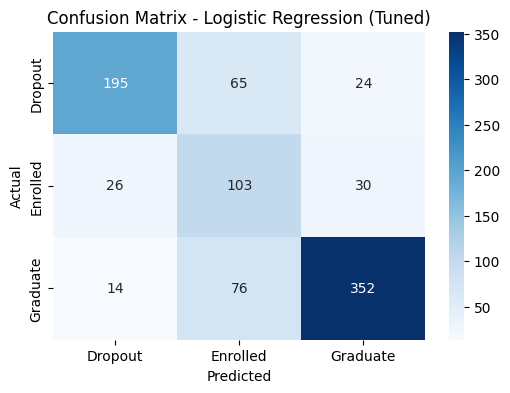

In [29]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "saga"],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n=== LOGISTIC REGRESSION TUNING ===")
print("Best params:", grid.best_params_)
print(f"Best CV Macro F1: {grid.best_score_:.4f}")

best_logreg = grid.best_estimator_

results = []
results.append(
    evaluate_model_detailed(
        name="Logistic Regression (Tuned)",
        pipeline=best_logreg,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        class_names=label_encoder.classes_
    )
)


=== DECISION TREE TUNING ===
Best params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV Macro F1: 0.6727

MODEL: Decision Tree (Tuned)
Accuracy        : 0.6768
Macro Precision : 0.6763
Macro Recall    : 0.6639
Macro F1-score  : 0.6480

Classification Report:
              precision    recall  f1-score   support

     Dropout     0.8398    0.6092    0.7061       284
    Enrolled     0.3549    0.6541    0.4602       159
    Graduate     0.8342    0.7285    0.7778       442

    accuracy                         0.6768       885
   macro avg     0.6763    0.6639    0.6480       885
weighted avg     0.7499    0.6768    0.6977       885



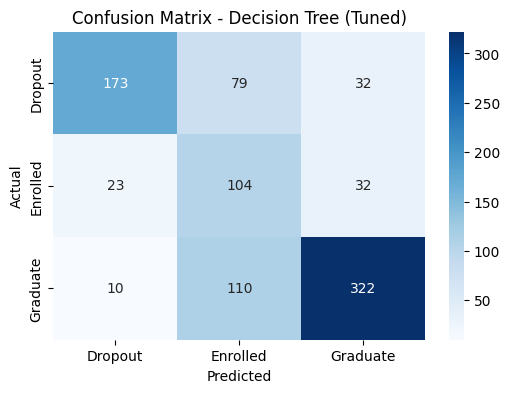

In [30]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("\n=== DECISION TREE TUNING ===")
print("Best params:", grid_dt.best_params_)
print(f"Best CV Macro F1: {grid_dt.best_score_:.4f}")

best_dt = grid_dt.best_estimator_

results.append(
    evaluate_model_detailed(
        name="Decision Tree (Tuned)",
        pipeline=best_dt,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        class_names=label_encoder.classes_
    )
)

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\n=== RANDOM FOREST TUNING ===")
print("Best params:", grid_rf.best_params_)
print(f"Best CV Macro F1: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_

results.append(
    evaluate_model_detailed(
        name="Random Forest (Tuned)",
        pipeline=best_rf,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        class_names=label_encoder.classes_
    )
)

In [ ]:
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

param_grid_svm = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("\n=== SVM TUNING ===")
print("Best params:", grid_svm.best_params_)
print(f"Best CV Macro F1: {grid_svm.best_score_:.4f}")

best_svm = grid_svm.best_estimator_

results.append(
    evaluate_model_detailed(
        name="SVM (Tuned)",
        pipeline=best_svm,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        class_names=label_encoder.classes_
    )
)

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="Macro F1", ascending=False)

print("\n=== MODEL COMPARISON ===")
print(results_df.round(4))